In [ ]:
!pip install -q diffusers transformers accelerate opencv-python torch torchvision xformers

In [ ]:
import torch
import cv2
import numpy as np
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
from transformers import pipeline


In [ ]:
depth_estimator = pipeline('depth-estimation')

def get_depth_map(image):
    image = depth_estimator(image)['depth']
    image = np.array(image)
    image = image[:, :, None]
    image = np.concatenate([image, image, image], axis=2)
    return Image.fromarray(image)

[transformers] No model was supplied, defaulted to Intel/dpt-large and revision bc15f29.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

[transformers] DPTForDepthEstimation LOAD REPORT from: Intel/dpt-large
Key                                                            | Status  | 
---------------------------------------------------------------+---------+-
neck.fusion_stage.layers.0.residual_layer1.convolution2.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-depth", torch_dtype=torch.float16
)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", controlnet=controlnet, torch_dtype=torch.float16
)

pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_model_cpu_offload()
pipe.enable_xformers_memory_efficient_attention() 

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

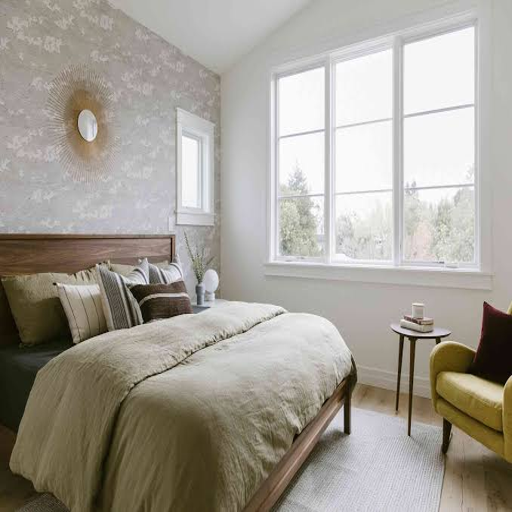

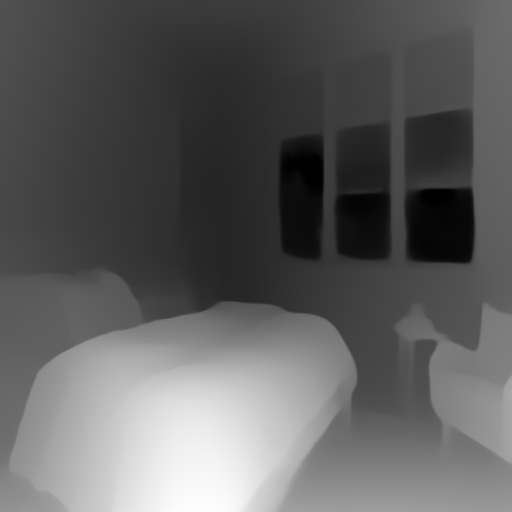

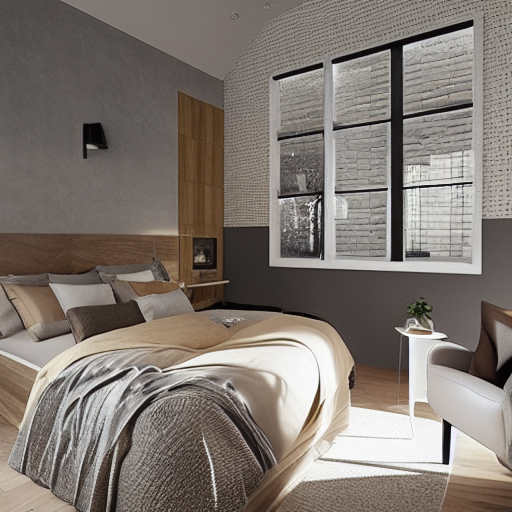

In [ ]:
init_image = Image.open("your_room_image.jpg").convert("RGB").resize((512, 512))
depth_map = get_depth_map(init_image)

prompt = "A highly detailed, photorealistic modern bedroom, wooden furniture, warm lighting, architectural digest style, 8k"
negative_prompt = "ugly, deformed, blurry, poor quality, watermark, artificial"

output_image = pipe(
    prompt,
    image=depth_map,
    negative_prompt=negative_prompt,
    num_inference_steps=25,
    controlnet_conditioning_scale=0.8 
).images[0]

output_image.save("modern_room.png")

display(init_image)
display(depth_map)
display(output_image)